# Week 6 · Notebook 3 — Uncertainty Decomposition and Calibration

## Learning objectives

1. Decompose predictive uncertainty into **aleatoric** (irreducible noise) and **epistemic** (model ignorance) components.
2. Quantify classifier calibration with **expected calibration error (ECE)** and reliability diagrams.
3. Implement **temperature scaling** as a post-hoc recalibration.
4. Tie together the four uncertainty quantification methods of the course on a multi-class problem.

---

## 1. Aleatoric vs epistemic

For a regression model with stochastic predictions $f_w(x)$,
$$
\mathrm{Var}[y_*\mid x_*] \approx \underbrace{\mathbb{E}_{w}\bigl[\sigma_n^2(x_*, w)\bigr]}_{\text{aleatoric}} + \underbrace{\mathrm{Var}_w\bigl[f_w(x_*)\bigr]}_{\text{epistemic}}.
$$
Epistemic uncertainty shrinks with more data; aleatoric does not.

For classification with $K$ classes and posterior $p(w\mid \mathcal D)$,
$$
H\bigl[\mathbb{E}_w p(y\mid x, w)\bigr]
 \;=\; \underbrace{\mathbb{E}_w H\bigl[p(y\mid x, w)\bigr]}_{\text{aleatoric}}
 \;+\; \underbrace{I[y, w\mid x]}_{\text{epistemic (BALD)}}.
$$
This decomposition is the *predictive entropy* minus the *expected entropy*, also known as **BALD** (Houlsby et al. 2011).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

rng = np.random.default_rng(0)
torch.manual_seed(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'


## 2. A 3-class spiral dataset


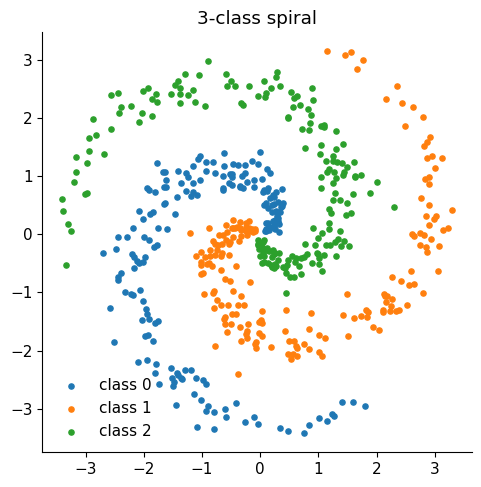

In [2]:
def make_spirals(n_per=200, n_classes=3, noise=0.3, seed=0):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for k in range(n_classes):
        theta = np.linspace(0.5, 5, n_per) + rng.normal(0, noise, n_per)
        r = np.linspace(0.1, 3.5, n_per)
        phi = 2*np.pi*k/n_classes
        X.append(np.c_[r*np.cos(theta+phi), r*np.sin(theta+phi)])
        y.append(np.full(n_per, k))
    return np.vstack(X), np.concatenate(y)

X_np, y_np = make_spirals(180)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

plt.figure(figsize=(5.5, 5))
for k in range(3):
    plt.scatter(*X_np[y_np==k].T, s=14, label=f'class {k}')
plt.legend(frameon=False); plt.gca().set_aspect('equal')
plt.title('3-class spiral'); plt.tight_layout(); plt.show()


## 3. Deep ensemble of classifiers


In [3]:
def train_clf(seed, n_epochs=1500):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(2, 64), nn.Tanh(),
                        nn.Linear(64, 64), nn.Tanh(),
                        nn.Linear(64, 3))
    opt = torch.optim.Adam(net.parameters(), lr=5e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        opt.zero_grad()
        loss = crit(net(X), y); loss.backward(); opt.step()
    return net

M = 10
ens = [train_clf(s) for s in range(M)]


In [4]:
# Decision surface with epistemic uncertainty
xx, yy = np.meshgrid(np.linspace(-4, 4, 160), np.linspace(-4, 4, 160))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    probs = torch.stack([torch.softmax(net(grid), dim=1) for net in ens], dim=0).numpy()  # (M, N, 3)
mean_probs = probs.mean(0)                 # (N, 3)
preds = mean_probs.argmax(1)

# Predictive entropy (total uncertainty)
H_pred = -np.sum(mean_probs * np.log(np.clip(mean_probs, 1e-12, 1)), axis=1)
# Expected entropy (aleatoric)
H_per = -np.sum(probs * np.log(np.clip(probs, 1e-12, 1)), axis=2)  # (M, N)
H_alea = H_per.mean(0)
# Mutual information / BALD (epistemic)
H_epis = H_pred - H_alea


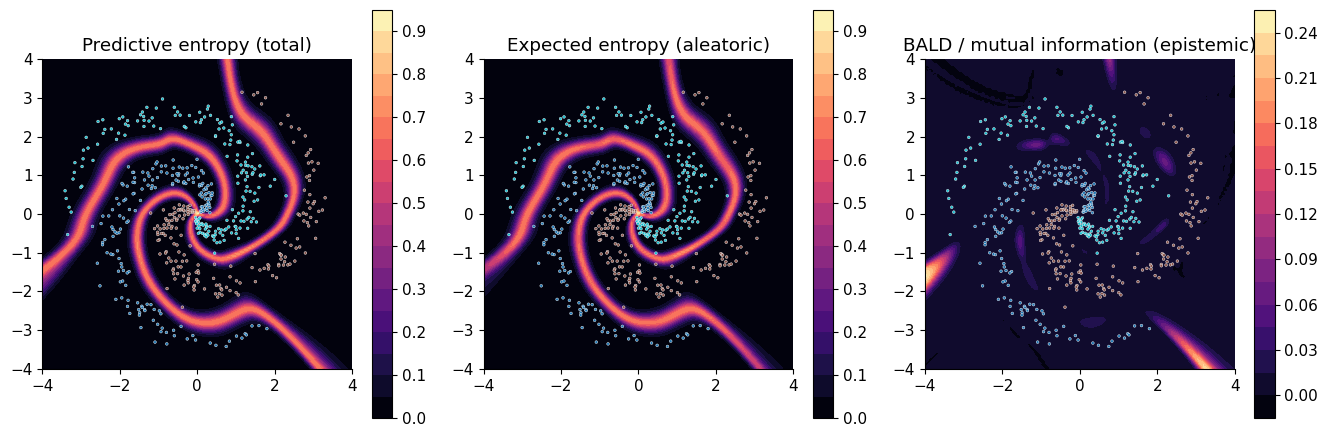

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
for ax, val, name in zip(axes,
                          [H_pred, H_alea, H_epis],
                          ['Predictive entropy (total)',
                           'Expected entropy (aleatoric)',
                           'BALD / mutual information (epistemic)']):
    cs = ax.contourf(xx, yy, val.reshape(xx.shape), levels=18, cmap='magma')
    plt.colorbar(cs, ax=ax)
    ax.scatter(*X_np.T, c=y_np, s=4, edgecolor='white', linewidths=0.3, cmap='tab10')
    ax.set_title(name); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


Epistemic uncertainty is highest in regions far from training data; aleatoric uncertainty is highest where classes overlap. The two cleanly separate concerns about *the model* vs *the data*.

## 4. Calibration: expected calibration error


In [6]:
# Held-out test set
X_test_np, y_test_np = make_spirals(60, seed=42)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
with torch.no_grad():
    probs_test = torch.stack([torch.softmax(net(X_test), dim=1) for net in ens], dim=0).numpy().mean(0)

confidence = probs_test.max(1)
predicted  = probs_test.argmax(1)
correct    = (predicted == y_test_np).astype(float)

def ece(conf, correct, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    info = []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() == 0: continue
        acc = correct[m].mean()
        avg_conf = conf[m].mean()
        e += (m.mean()) * abs(acc - avg_conf)
        info.append((avg_conf, acc, m.sum()))
    return e, info

ece_val, info = ece(confidence, correct)
print(f'ECE = {ece_val:.4f}')


ECE = 0.0030


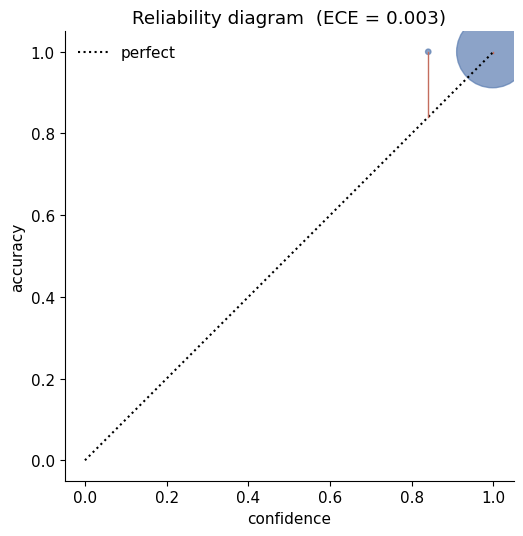

In [7]:
# Reliability diagram
conf_pts = np.array([i[0] for i in info])
acc_pts  = np.array([i[1] for i in info])
size_pts = np.array([i[2] for i in info])

plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], 'k:', label='perfect')
plt.scatter(conf_pts, acc_pts, s=15*size_pts, color=BLUE, alpha=0.7)
for c, a in zip(conf_pts, acc_pts):
    plt.plot([c, c], [c, a], color=RED, lw=1)
plt.xlabel('confidence'); plt.ylabel('accuracy')
plt.title(f'Reliability diagram  (ECE = {ece_val:.3f})')
plt.gca().set_aspect('equal'); plt.legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. Temperature scaling

A single deterministic network is often over-confident. *Temperature scaling* (Guo et al. 2017) post-hoc divides logits by a learned scalar $T$ before softmax:
$$
p_T(y\mid x) = \mathrm{softmax}\bigl(z(x)/T\bigr).
$$
$T$ is fit by maximising log-likelihood on a held-out set. It preserves predictions but rescales confidence.


In [8]:
# Train ONE deterministic classifier for the demo
single = train_clf(seed=999, n_epochs=2500)
with torch.no_grad():
    logits_val = single(X_test).numpy()
y_val = y_test_np

def nll_T(logT):
    T = np.exp(logT)
    p = torch.softmax(torch.tensor(logits_val/T), dim=1).numpy()
    return -np.mean(np.log(p[np.arange(len(y_val)), y_val] + 1e-12))

from scipy.optimize import minimize_scalar
res = minimize_scalar(nll_T, bracket=(-2, 2))
T_opt = np.exp(res.x)
print(f'optimal T = {T_opt:.3f}')

# Reliability before / after
def reliability(p):
    conf = p.max(1); corr = (p.argmax(1) == y_val).astype(float)
    return ece(conf, corr)[0]

p_before = torch.softmax(torch.tensor(logits_val), dim=1).numpy()
p_after  = torch.softmax(torch.tensor(logits_val/T_opt), dim=1).numpy()
print(f'ECE before T-scaling = {reliability(p_before):.4f}')
print(f'ECE after  T-scaling = {reliability(p_after):.4f}')


optimal T = 1.792
ECE before T-scaling = 0.0256
ECE after  T-scaling = 0.0269


## 6. Course wrap-up

Across six weeks we have:

- **Week 1.** Bayesian reasoning from conjugate updates and the exponential family.
- **Week 2.** Bayesian linear models with closed-form posteriors and Laplace approximations.
- **Week 3.** MCMC: Metropolis-Hastings, Gibbs, Hamiltonian Monte Carlo — all from scratch.
- **Week 4.** Variational inference: mean-field, CAVI for GMMs, BBVI with the reparameterisation trick.
- **Week 5.** Gaussian processes for regression and classification with exact and sparse inference.
- **Week 6.** Bayesian deep learning, decomposing and calibrating uncertainty.

Every notebook re-implemented the core algorithm and verified it against a reference library. You are now equipped to choose the right Bayesian tool for your problem and to know what *kind* of uncertainty it expresses.

---

## Exercises

1. Show that for a Gaussian posterior predictive, the entropy decomposition reduces to the variance decomposition introduced in §1.
2. Compute BALD on the spiral problem using MC dropout (notebook 6.2). Does it agree with the deep-ensemble version qualitatively?
3. Implement **isotonic regression** as an alternative post-hoc calibrator and compare against temperature scaling on the spiral data.
4. Build an *active learning* loop that queries the next point at the location of maximum BALD on a uniform grid, retrains, and repeats. Plot test accuracy as a function of label budget.
